In [1]:
from vkt.core import Crossing, StrandRef,connect, disconnect
from vkt.core import parse_gauss_code, VirtualLink, VirtualLinkDiagram
from vkt.core.arc_routing_strandref import route_arc_from_strandref


In [2]:
gauss_code = "O1-O2-U1-U2-"
crossings = parse_gauss_code(gauss_code)
link = VirtualLink(crossings)

In [3]:
link.crossings

[Crossing(id=0, kind=classical, sign=-1),
 Crossing(id=1, kind=classical, sign=-1)]

In [4]:
link_diagram=link.to_diagram()

In [5]:
link_diagram.crossings

[Crossing(id=0, kind=classical, sign=-1),
 Crossing(id=1, kind=classical, sign=-1)]

In [ ]:
#link_diagram.admit_virtual_crossing(link_diagram.crossings[0].ref(0),link_diagram.crossings[0].ref(1),1,0)

Crossing(id=2, kind=virtual, sign=None)

In [6]:
link_diagram.crossings

[Crossing(id=0, kind=classical, sign=-1),
 Crossing(id=1, kind=classical, sign=-1)]

In [7]:
 link_diagram.components()

[[StrandRef(crossing=0, strand=0),
  StrandRef(crossing=1, strand=0),
  StrandRef(crossing=0, strand=1),
  StrandRef(crossing=1, strand=1)]]

In [8]:
route_arc_from_strandref(link_diagram.crossings[0].ref(0))

([0, 4, 4], [1, 1, 3])

In [9]:
route_arc_from_strandref(link_diagram.crossings[0].ref(1))

([1, 3, 3], [0, 0, 4])

In [10]:
route_arc_from_strandref(link_diagram.crossings[1].ref(0))

([4, -1, -1], [5, 5, 0])

In [11]:
route_arc_from_strandref(link_diagram.crossings[1].ref(1))

([5, 5, -2, -2, 0], [4, 6, 6, -1, -1])

In [2]:
gc = 'O1-U2-O3+U1-O4-U5-O6-U3+O2-U4-O5-U6-'
crossings = parse_gauss_code(gc)
link = VirtualLink(crossings)
link_diagram= VirtualLinkDiagram(link)

In [3]:
link_diagram.compute_arc_routes()

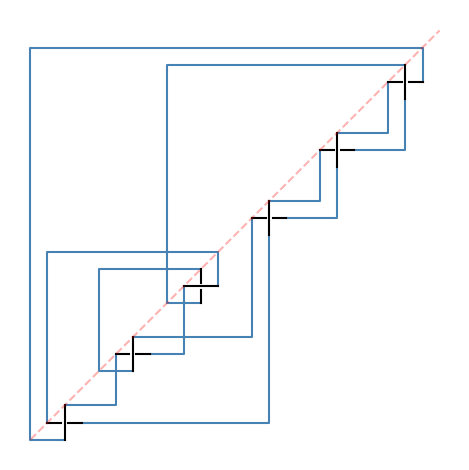

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

all_vals = []

# Plot arcs
for crossing in link.crossings:
    for i in range(2):
        result = route_arc_from_strandref(crossing.ref(i))
        if result is None:
            continue
        xs, ys = result
        all_vals.extend(xs)
        all_vals.extend(ys)
        ax.plot(xs, ys, color='steelblue')

# Plot crossings
for n, crossing in enumerate(link.crossings):
    cx, cy = 4 * n, 4 * n
    if crossing.sign == 1:  # positive: x-axis over, y-axis broken
        ax.plot([cx - 1, cx + 1], [cy, cy], color='black')
        ax.plot([cx, cx], [cy - 1, cy - 0.2], color='black')
        ax.plot([cx, cx], [cy + 0.2, cy + 1], color='black')
    else:  # negative: y-axis over, x-axis broken
        ax.plot([cx, cx], [cy - 1, cy + 1], color='black')
        ax.plot([cx - 1, cx - 0.2], [cy, cy], color='black')
        ax.plot([cx + 0.2, cx + 1], [cy, cy], color='black')

lim = [min(all_vals), max(all_vals)]
ax.plot(lim, [v + 1 for v in lim], color='red', linestyle='--', alpha = .3)

ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.show()

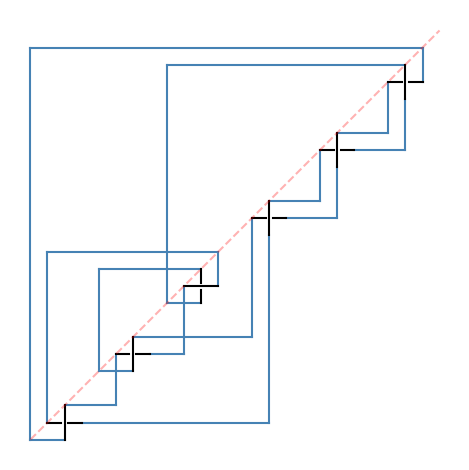

<Axes: >

In [4]:
link_diagram.plot()

In [5]:
link_diagram.arc_routes[link_diagram.crossings[0].ref(0)]

[Segment[H]((0, 1) → (3, 1)), Segment[V]((3, 1) → (3, 4))]

In [1]:
from vkt.core import Crossing, StrandRef,connect, disconnect
from vkt.core import parse_gauss_code, VirtualLink, VirtualLinkDiagram
from vkt.core.arc_routing_strandref import route_arc_from_strandref

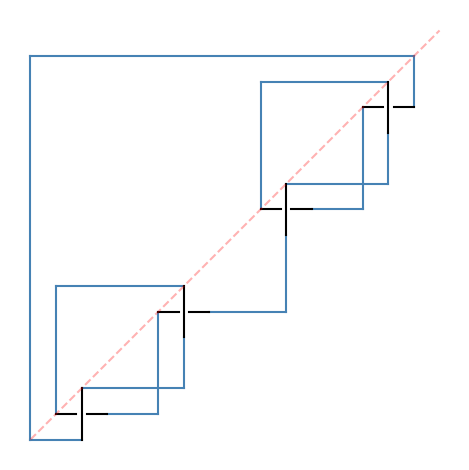

1
3


In [14]:
gc =  'O1-O2-U1-U2-O3-O4-U3-U4-'
crossings = parse_gauss_code(gc)
link = VirtualLink(crossings)
link_diagram= VirtualLinkDiagram(link)
#link_diagram.compute_arc_routes()
link_diagram.plot()
link_diagram.compute_virtual_crossings()
print(len(link_diagram.components()))
print(len(link_diagram.seifert_components()))

In [8]:
sc= link_diagram.seifert_components()
sc[3]

[StrandRef(crossing=2, strand=0),
 StrandRef(crossing=11, strand=1),
 StrandRef(crossing=11, strand=0),
 StrandRef(crossing=7, strand=1),
 StrandRef(crossing=7, strand=0),
 StrandRef(crossing=2, strand=1)]

In [7]:
link_diagram.arc_routes[link_diagram.crossings[0].ref(0)]


[Segment[H]((0, 1) → (3, 1)), Segment[V]((3, 1) → (3, 4))]

In [13]:
segments = link_diagram.arc_routes[link_diagram.crossings[4].ref(0)]
for i, seg in enumerate(segments):
    print(i,seg)

0 Segment[H]((16, 17) → (2, 17))
1 Segment[V]((2, 17) → (2, 3))
2 Segment[H]((2, 3) → (4, 3))


In [3]:
def arc_position(link_diagram, ref, x, y):
    segments = link_diagram.arc_routes[ref]
    for i, seg in enumerate(segments):
        if seg.is_horizontal:
            if seg.start[1] == y:
                x_min = min(seg.start[0], seg.end[0])
                x_max = max(seg.start[0], seg.end[0])
                if x_min < x < x_max:
                    length = abs(seg.end[0] - seg.start[0])
                    t_seg = abs(x - seg.start[0]) / length
                    return i + t_seg
        else:  # vertical
            if seg.start[0] == x:
                y_min = min(seg.start[1], seg.end[1])
                y_max = max(seg.start[1], seg.end[1])
                if y_min < y < y_max:
                    length = abs(seg.end[1] - seg.start[1])
                    t_seg = abs(y - seg.start[1]) / length
                    return i + t_seg
    return None

In [16]:
arc_position(link_diagram,link_diagram.crossings[4].ref(0),3,3 )


2.5

In [4]:
def is_max(link_diagram, ref1, ref2, x, y, remaining):
    pos1 = arc_position(link_diagram,ref1, x, y)
    pos2 = arc_position(link_diagram,ref2, x, y)

    # Check ref1: any remaining intersection further forward?
    for (r1, r2, xi, yi) in remaining:
        if (xi, yi) == (x, y):
            continue
        if r1 == ref1 or r2 == ref1:
            p = arc_position(ref1, xi, yi)
            if p is not None and p > pos1:
                return False

    # Check ref2: any remaining intersection further forward?
    for (r1, r2, xi, yi) in remaining:
        if (xi, yi) == (x, y):
            continue
        if r1 == ref2 or r2 == ref2:
            p = arc_position(ref2, xi, yi)
            if p is not None and p > pos2:
                return False

    return True

In [5]:
remaining = link_diagram.find_virtual_crossings()
ref1 = link_diagram.crossings[4].ref(0)
ref2 = link_diagram.crossings[0].ref(0)
x = 3 
y = 3
is_max(link_diagram, ref1, ref2, x, y, remaining)

TypeError: arc_position() missing 1 required positional argument: 'y'

In [4]:
remaining = link_diagram.find_virtual_crossings()
ref1 = link_diagram.crossings[0].ref(1)
ref2 = link_diagram.crossings[3].ref(1)
x = 19 
y = 12
link_diagram.is_max(ref1, ref2, x, y, remaining)

True

In [5]:
remaining = link_diagram.find_virtual_crossings()
ref2 = link_diagram.crossings[1].ref(0)
ref1 = link_diagram.crossings[3].ref(1)
x = 15 
y = 12
link_diagram.is_max(ref1, ref2, x, y, remaining)

False

In [28]:
arc_position(link_diagram,link_diagram.crossings[3].ref(1),15,12 )

0.2857142857142857

In [29]:
arc_position(link_diagram,link_diagram.crossings[3].ref(1),19,12 )

0.8571428571428571

In [8]:
def is_max(link_diagram, ref1, ref2, x, y, remaining):
    pos1 = arc_position(link_diagram,ref1, x, y)
    pos2 = arc_position(link_diagram,ref2, x, y)

    # Check ref1: any remaining intersection further forward?
    for (r1, r2, xi, yi) in remaining:
        if (xi, yi) == (x, y):
            continue
        if r1 == ref1 or r2 == ref1:
            p = arc_position(link_diagram,ref1, xi, yi)
            if p is not None and p > pos1:
                return False

    # Check ref2: any remaining intersection further forward?
    for (r1, r2, xi, yi) in remaining:
        if (xi, yi) == (x, y):
            continue
        if r1 == ref2 or r2 == ref2:
            p = arc_position(link_diagram,ref2, xi, yi)
            if p is not None and p > pos2:
                return False

    return True

In [6]:
remaining = link_diagram.find_virtual_crossings()
ref2 = link_diagram.crossings[1].ref(0)
ref1 = link_diagram.crossings[3].ref(1)
x = 15 
y = 12
link_diagram.is_max(ref2, ref1, x, y, remaining)

False

In [7]:
remaining = link_diagram.find_virtual_crossings()
ref2 = link_diagram.crossings[4].ref(0)
ref1 = link_diagram.crossings[0].ref(0)
x = 3 
y = 3
link_diagram.is_max(ref2, ref1, x, y, remaining)

True